In [1]:
import pandas as pd
import glob #used to import files from the folder together rather than one by one
import matplotlib.pyplot as plt

In [2]:
#loading data files

In [3]:
#power generation data
path1="C:/Users/hp/Downloads/python proj/dataset/power generation/*.csv"
files1=glob.glob(path1) 

df_gen = pd.concat([pd.read_csv(f) for f in files1], ignore_index=True) 

#power supply data
path2="C:/Users/hp/Downloads/python proj/dataset/power supply position/*.csv"
files2=glob.glob(path2) 

df_supply = pd.concat([pd.read_csv(f) for f in files2], ignore_index=True) 

consumption = pd.read_excel("C:/Users/hp/Downloads/python proj/dataset/Electricity Consumption.xlsx")
capacity = pd.read_excel("C:/Users/hp/Downloads/python proj/dataset/Electricity Installed Capacity.xlsx")
consumers = pd.read_excel("C:/Users/hp/Downloads/python proj/dataset/No. of Consumers.xlsx")
revenue = pd.read_excel("C:/Users/hp/Downloads/python proj/dataset/Revenue from Electricity Sales.xlsx")

In [4]:
#understanding data and EDA

In [5]:
print(len(files1), len(files2))
df_gen.head()
df_gen.columns

6 10


Index(['Sl. No.', 'Regions', 'State', 'Sector Category', 'Category',
       'Stations', 'Monitored Capacity (MW) - Col (1)',
       'Target April 2023 to Mach 2024 - Col (2)',
       'August` 2023 - Program - Col (3)', 'August` 2023 - Actual - Col (4)',
       ...
       'April` 2023 to September` 2023 - Actual - Col (9)',
       'April` 2023 to September` 2023 - Actual Same Period 2022-23 - Col (10)',
       'April` 2023 to September` 2023 - % of Program Col. (9/8) - Col (11)',
       'April` 2023 to September` 2023 - % of Last Year Col. (9/10) - Col (12)',
       'Plant Load Factor (%) - September` 2023 - Program - Col (13)',
       'Plant Load Factor (%) - September` 2023 - Actual - Col (14)',
       'Plant Load Factor (%) - September` 2023 - Actual Same Month 2022-23 - Col (15)',
       'Plant Load Factor (%) - April` 2023 to September` 2023 - Program - Col (16)',
       'Plant Load Factor (%) - April` 2023 to September` 2023 - Actual - Col (17)',
       'Plant Load Factor (%) - Ap

In [6]:
consumption.head()
consumption.columns

Index(['Year', 'Category', 'Electricity Consumption (in MU)'], dtype='object')

In [7]:
consumption = consumption.rename(columns={
    'Electricity Consumption (in MU)': 'Consumption'
})
consumption['Category'].unique()

array(['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others',
       'Public Services', 'Railways'], dtype=object)

In [8]:
consumption['Year'].unique()

array(['2009-10', '2010-11', '2011-12', '2012-13', '2013-14', '2014-15',
       '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21',
       '2021-22', '2022-23', '2023-24', '2024-25'], dtype=object)

In [9]:
consumption['Year'] = consumption['Year'].str[:4].astype(int)

In [10]:
consumption = consumption.dropna(subset=['Year'])
consumption['Year'] = consumption['Year'].astype(int)

In [11]:
consumption['Year'].unique()

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024])

In [12]:
print(capacity.columns)
print(consumers.columns)
print(revenue.columns)

Index(['Parameter', '31.12.1947', '31.12.1950', '31-03-1956 (end of 1st plan)',
       '31-03-1961 (end of 2nd plan)', '31-03-1966 (end of 3rd plan)',
       '31-03-1969 (end of 3 annual plans)', '31-03-1974 (end of 4th plan)',
       '31-03-1979 (end of 5th plan)', '31-03-1980 (end of annual plan)',
       '31-03-1985 (end of 6th plan)', '31-03-1990 (end of 7th plan)',
       '31-03-1992 (end of 2 annual plans)', '31-03-1997 (end of 8th plan)',
       '31-03-2002 (end of 9th plan)', '31-03-2007 (end of 10th plan)',
       '2007-08', '2008-09', '2009-10', '2010-11', '2011-12', '2012-13',
       '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19',
       '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25',
       '2025-26'],
      dtype='object')
Index(['Year', 'Category', 'No. of Consumers'], dtype='object')
Index(['Year', 'Category', 'Revenue (in Rs Crores)'], dtype='object')


In [13]:
capacity_melted = capacity.melt(
    id_vars='Parameter',
    var_name='Year',
    value_name='Capacity'
)
capacity_melted.head()

,Parameter,Year,Capacity
0,Coal (in MW),31.12.1947,756
1,Oil & Gas (in MW),31.12.1947,98
2,Nuclear (in MW),31.12.1947,-
3,Hydro (in MW),31.12.1947,508
4,Solar (in MW),31.12.1947,-


In [14]:
capacity_melted['Year'] = capacity_melted['Year'].str.extract(r'(\d{4})')
capacity_melted['Year'] = capacity_melted['Year'].astype(float)
capacity_melted = capacity_melted.dropna(subset=['Year'])
capacity_melted['Year'] = capacity_melted['Year'].astype(int)

In [15]:
capacity_melted = capacity_melted.rename(columns={
    'Parameter': 'Category'
})

In [16]:
consumers = consumers.rename(columns={
    'No. of Consumers': 'Consumers'
})
consumers['Year'] = consumers['Year'].str[:4].astype(int)
revenue = revenue.rename(columns={
    'Revenue (in Rs Crores)': 'Revenue'
})
revenue['Year'] = revenue['Year'].str[:4].astype(int)

In [17]:
consumption['Category'].unique()
capacity_melted['Category'].unique()

array(['Coal (in MW)', 'Oil & Gas (in MW)', 'Nuclear (in MW)',
       'Hydro (in MW)', 'Solar (in MW)', 'Solar - Ground Mounted (in MW)',
       'Solar - Roof-top (in MW)', 'Solar - Hybrid-solar (in MW)',
       'Solar - Off-grid (in MW)', 'Wind (in MW)', 'Small-Hydro (in MW)',
       'Bio Power (in MW)', 'Bio-power - Bagasse (in MW)',
       'Bio-power - Non-bagasse (in MW)',
       'Bio-power - Waste-to-energy (in MW)',
       'Bio-power - Waste-to-energy-off-grid (in MW)', 'RES-Total ',
       'Total', 'Growth Rate (in %)'], dtype=object)

In [18]:
df_demand = consumption.merge(consumers, on=['Year','Category'])
df_demand = df_demand.merge(revenue, on=['Year','Category'])
df_demand.head()

,Year,Category,Consumption,Consumers,Revenue
0,2009,Agriculture,119491.83,17860081.0,10635.0
1,2009,Commercial,58971.41,21370844.0,24340.0
2,2009,Domestic,141844.72,164085729.0,32474.0
3,2009,Industrial,297621.16,3342439.0,76490.0
4,2009,Others,8962.47,1180553.0,16140.0


In [19]:
df_supply_clean = capacity_melted.copy()

In [20]:
df_demand.head()
df_demand.columns

Index(['Year', 'Category', 'Consumption', 'Consumers', 'Revenue'], dtype='object')

In [21]:
df_demand.info()
df_demand.describe()
df_demand.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         80 non-null     int64  
 1   Category     80 non-null     object 
 2   Consumption  80 non-null     float64
 3   Consumers    80 non-null     float64
 4   Revenue      80 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 3.3+ KB


Year           0
Category       0
Consumption    0
Consumers      0
Revenue        0
dtype: int64

In [22]:
df_demand.duplicated().sum()

np.int64(0)

In [23]:
df_demand.groupby('Year').size()

Year
2009    6
2010    6
2012    6
2013    6
2014    6
2015    5
2016    5
2017    5
2018    5
2019    5
2020    5
2021    5
2022    5
2023    5
2024    5
dtype: int64

In [24]:
df_supply_clean.info()
df_supply_clean.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646 entries, 0 to 645
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  646 non-null    object
 1   Year      646 non-null    int64 
 2   Capacity  628 non-null    object
dtypes: int64(1), object(2)
memory usage: 15.3+ KB


Category     0
Year         0
Capacity    18
dtype: int64

In [25]:
df_supply_clean['Category'].unique()

array(['Coal (in MW)', 'Oil & Gas (in MW)', 'Nuclear (in MW)',
       'Hydro (in MW)', 'Solar (in MW)', 'Solar - Ground Mounted (in MW)',
       'Solar - Roof-top (in MW)', 'Solar - Hybrid-solar (in MW)',
       'Solar - Off-grid (in MW)', 'Wind (in MW)', 'Small-Hydro (in MW)',
       'Bio Power (in MW)', 'Bio-power - Bagasse (in MW)',
       'Bio-power - Non-bagasse (in MW)',
       'Bio-power - Waste-to-energy (in MW)',
       'Bio-power - Waste-to-energy-off-grid (in MW)', 'RES-Total ',
       'Total', 'Growth Rate (in %)'], dtype=object)

In [26]:
df_gen.head()
df_gen.columns
df_gen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6155 entries, 0 to 6154
Columns: 107 entries, Sl. No. to Plant Load Factor (%) - April` 2023 to September` 2023 - Actual Same Peroid 2022-23 - Col (18)
dtypes: float64(100), int64(1), object(6)
memory usage: 5.0+ MB


In [27]:
df_supply.head()
df_supply.columns
df_supply.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   420 non-null    object 
 1   Month                   420 non-null    object 
 2   Energy Requirement MU   420 non-null    float64
 3   Energy Availability MU  420 non-null    float64
dtypes: float64(2), object(2)
memory usage: 13.3+ KB


In [28]:
df_demand[df_demand['Year'] == 2014]['Category']
df_demand[df_demand['Year'] == 2015]['Category']

30    Agriculture
31     Commercial
32       Domestic
33     Industrial
34         Others
Name: Category, dtype: object

In [29]:
df_demand = df_demand.fillna(0)

In [30]:
df_supply_clean['Capacity'] = pd.to_numeric(df_supply_clean['Capacity'], errors='coerce')
df_supply_clean = df_supply_clean.dropna(subset=['Capacity'])

In [31]:
df_supply_clean['Category'] = df_supply_clean['Category'].str.replace(r'\(in MW\)', '', regex=True)
df_supply_clean['Category'] = df_supply_clean['Category'].str.strip()

In [32]:
df_supply['Month'] = pd.to_datetime(df_supply['Month'], errors='coerce')
df_supply['Year'] = df_supply['Month'].dt.year

C:\Users\hp\AppData\Local\Temp\ipykernel_16128\2800118341.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_supply['Month'] = pd.to_datetime(df_supply['Month'], errors='coerce')


In [33]:
df_supply_yearly = df_supply.groupby(['Year'])[
    ['Energy Requirement MU', 'Energy Availability MU']
].sum().reset_index()

In [34]:
##########################---------DEMAND ANALYSIS---------------#########################################

<Axes: title={'center': 'Total Electricity Consumption Over Time'}, xlabel='Year'>

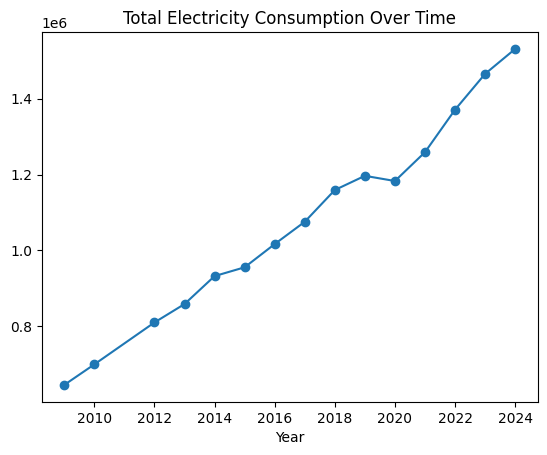

In [35]:
df_demand.groupby('Year')['Consumption'].sum().plot(
    kind='line', marker='o', title='Total Electricity Consumption Over Time'
)

<Axes: title={'center': 'Consumption by Category'}, ylabel='Category'>

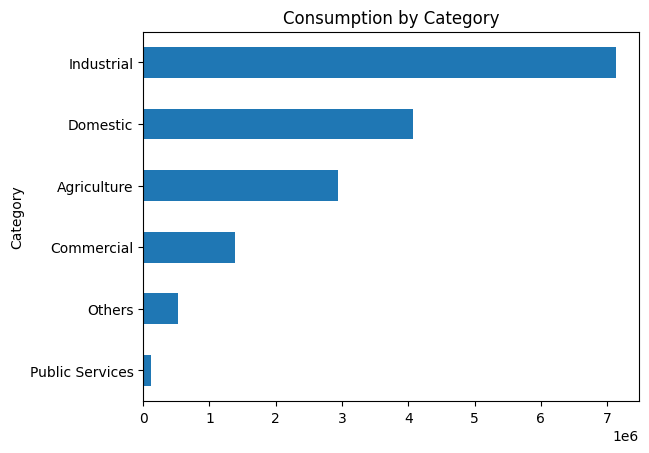

In [36]:
df_demand.groupby('Category')['Consumption'].sum().sort_values().plot(
    kind='barh', title='Consumption by Category'
)

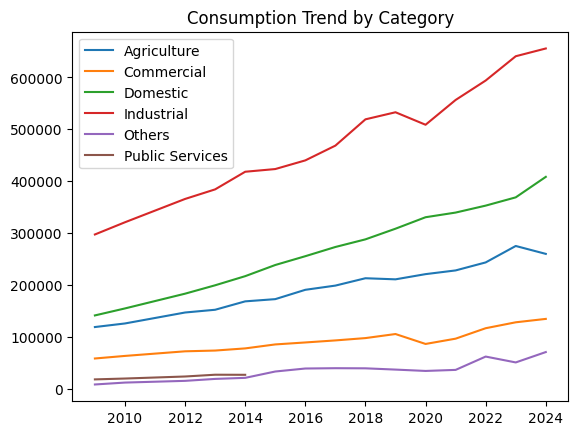

In [37]:
for cat in df_demand['Category'].unique():
    subset = df_demand[df_demand['Category'] == cat]
    plt.plot(subset['Year'], subset['Consumption'], label=cat)

plt.legend()
plt.title("Consumption Trend by Category")
plt.show()

<Axes: title={'center': 'Consumption vs Revenue'}, xlabel='Year'>

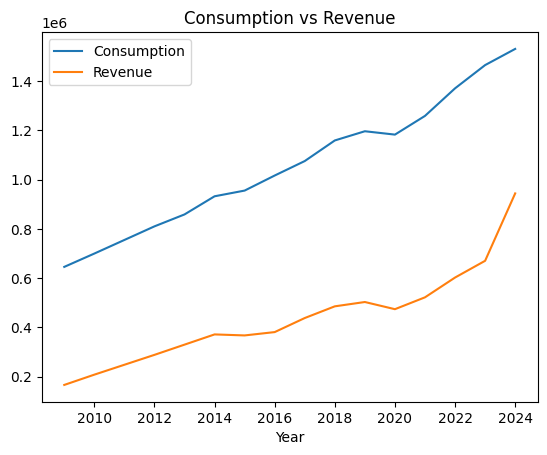

In [38]:
df_demand.groupby('Year')[['Consumption','Revenue']].sum().plot(
    kind='line', title='Consumption vs Revenue'
)

<Axes: title={'center': 'Number of Consumers Over Time'}, xlabel='Year'>

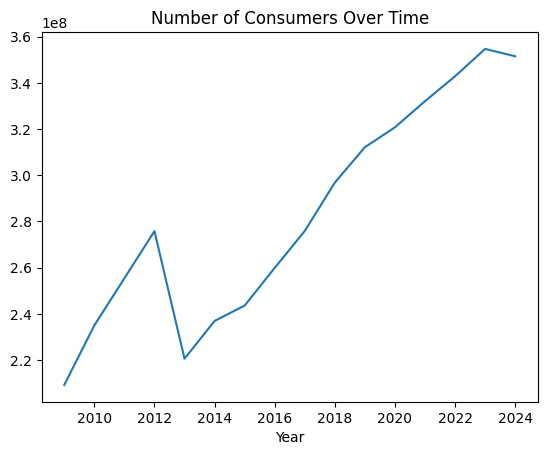

In [39]:
df_demand.groupby('Year')['Consumers'].sum().plot(
    kind='line', title='Number of Consumers Over Time'
)

In [40]:
df_demand[['Consumption','Consumers','Revenue']].corr()

,Consumption,Consumers,Revenue
Consumption,1.000000,0.210999,0.848038
Consumers,0.210999,1.000000,0.198750
Revenue,0.848038,0.198750,1.000000


In [41]:
##########################---------SUPPLY ANALYSIS---------------#########################################

<Axes: title={'center': 'Installed Capacity by Source'}, ylabel='Category'>

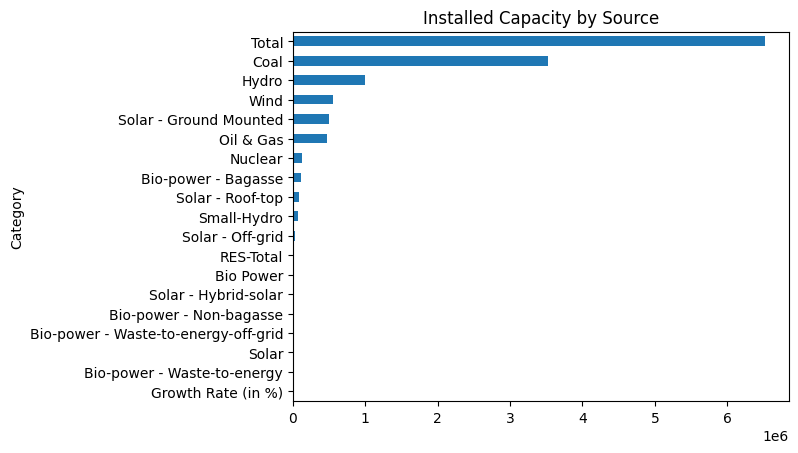

In [42]:
df_supply_clean.groupby('Category')['Capacity'].sum().sort_values().plot(
    kind='barh', title='Installed Capacity by Source'
)

<Axes: title={'center': 'Renewable Capacity Growth'}, xlabel='Year'>

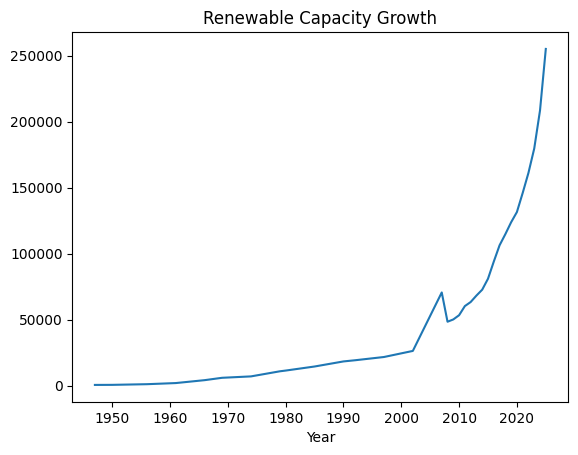

In [43]:
renewables = df_supply_clean[df_supply_clean['Category'].str.contains('Solar|Wind|Hydro', case=False)]

renewables.groupby('Year')['Capacity'].sum().plot(
    kind='line', title='Renewable Capacity Growth'
)

In [44]:
##########################---------SUPPLY VS DEMAND---------------#########################################

<Axes: title={'center': 'Energy Requirement vs Availability'}, xlabel='Year'>

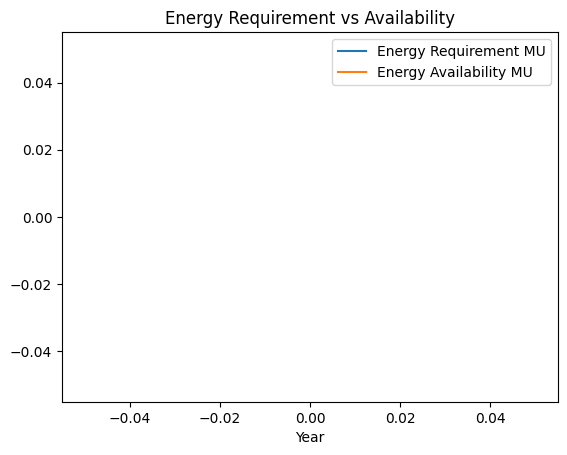

In [45]:
df_supply_yearly.plot(
    x='Year',
    y=['Energy Requirement MU','Energy Availability MU'],
    kind='line',
    title='Energy Requirement vs Availability'
)

<Axes: title={'center': 'Number of Consumers Over Time'}, xlabel='Year'>

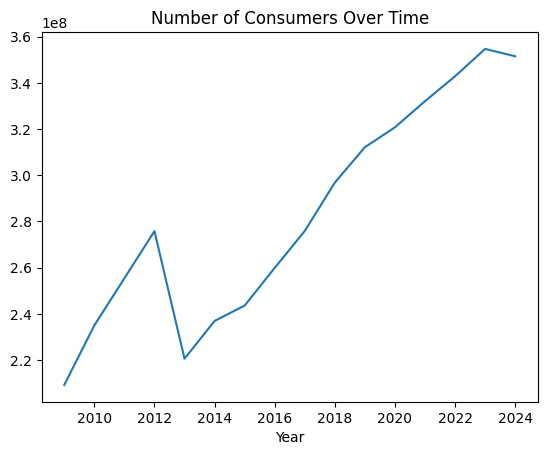

In [46]:
df_demand.groupby('Year')['Consumers'].sum().plot(
    kind='line', title='Number of Consumers Over Time'
)

<Axes: title={'center': 'Demand-Supply Gap'}, xlabel='Year'>

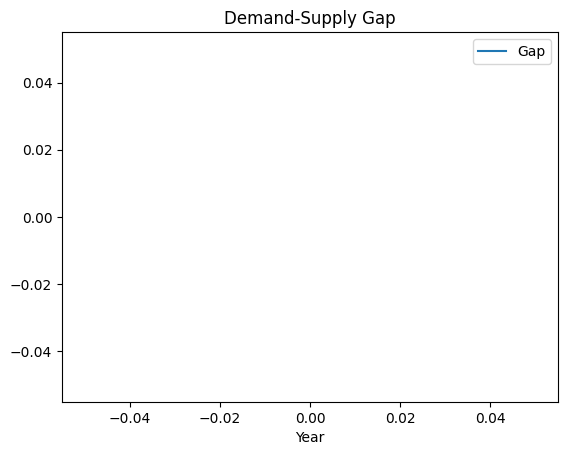

In [47]:
df_supply_yearly['Gap'] = (
    df_supply_yearly['Energy Requirement MU'] - df_supply_yearly['Energy Availability MU']
)
df_supply_yearly.plot(
    x='Year',
    y='Gap',
    kind='line',
    title='Demand-Supply Gap'
)

In [48]:
df_supply_yearly.head()

,Year,Energy Requirement MU,Energy Availability MU,Gap


In [49]:
df_supply_yearly['Gap'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Gap, dtype: float64

In [50]:
df_supply_yearly[['Energy Requirement MU', 'Energy Availability MU']]

,Energy Requirement MU,Energy Availability MU


In [51]:
df_supply.columns.tolist()

['State ', 'Month', 'Energy Requirement MU', 'Energy Availability MU', 'Year']

In [52]:
df_supply.columns = df_supply.columns.str.strip()

In [53]:
print(df_supply['Month'].head(10))
df_supply['Month'].isnull().sum()

0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
5   NaT
6   NaT
7   NaT
8   NaT
9   NaT
Name: Month, dtype: datetime64[ns]


np.int64(420)

In [54]:
#fixing the issue 
df_supply = pd.concat([pd.read_csv(f) for f in files2], ignore_index=True) 
df_supply['Month'].head(10)

0    Apr-23
1    Apr-23
2    Apr-23
3    Apr-23
4    Apr-23
5    Apr-23
6    Apr-23
7    Apr-23
8    Apr-23
9    Apr-23
Name: Month, dtype: object

In [55]:
df_supply['Year'] = df_supply['Month'].str[-2:]
df_supply['Year'] = df_supply['Year'].astype(int) + 2000

In [56]:
df_supply_yearly = df_supply.groupby('Year')[
    ['Energy Requirement MU', 'Energy Availability MU']
].sum().reset_index()

In [57]:
df_supply_yearly['Gap'] = (
    df_supply_yearly['Energy Requirement MU'] -
    df_supply_yearly['Energy Availability MU']
)

In [58]:
df_supply_yearly.head()
df_supply_yearly['Gap'].describe()

count       1.000000
mean     9991.217331
std              NaN
min      9991.217331
25%      9991.217331
50%      9991.217331
75%      9991.217331
max      9991.217331
Name: Gap, dtype: float64

In [59]:
df_supply['Month'].unique()

array(['Apr-23', 'Aug-23', 'Dec-23', 'Jul-23', 'Jun-23', 'Mar-23',
       'May-23', 'Nov-23', 'Oct-23', 'Sep-23'], dtype=object)

In [60]:
df_supply['Month'] = pd.to_datetime(df_supply['Month'], format='%b-%y')

In [61]:
df_supply = df_supply.sort_values('Month')

In [62]:
df_supply_monthly = df_supply.groupby('Month')[
    ['Energy Requirement MU', 'Energy Availability MU']
].sum().reset_index()

In [63]:
df_supply_monthly['Gap'] = (
    df_supply_monthly['Energy Requirement MU'] -
    df_supply_monthly['Energy Availability MU']
)

<Axes: title={'center': 'Monthly Energy Requirement vs Availability'}, xlabel='Month'>

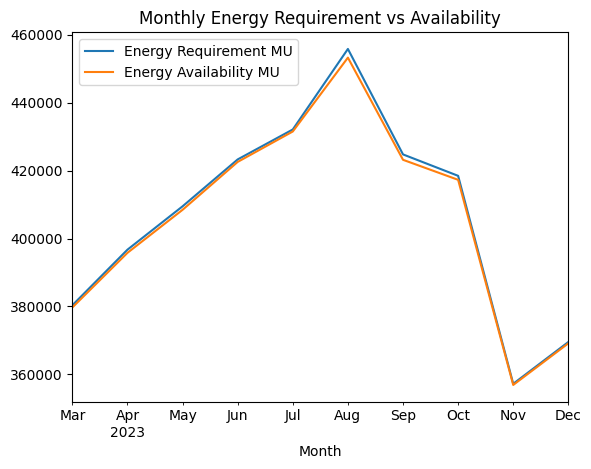

In [64]:
df_supply_monthly.plot(
    x='Month',
    y=['Energy Requirement MU','Energy Availability MU'],
    kind='line',
    title='Monthly Energy Requirement vs Availability'
)

<Axes: title={'center': 'Monthly Demand-Supply Gap'}, xlabel='Month'>

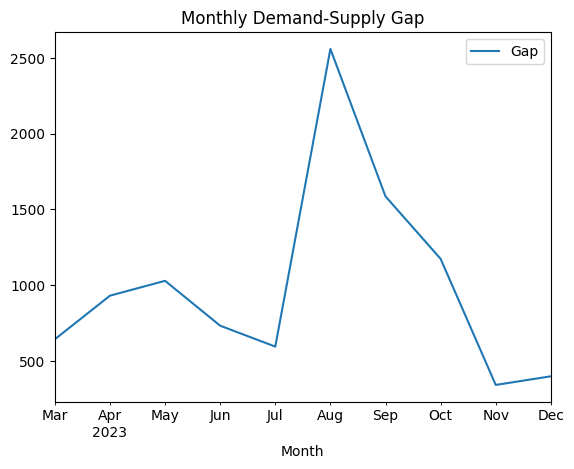

In [65]:
df_supply_monthly.plot(
    x='Month',
    y='Gap',
    kind='line',
    title='Monthly Demand-Supply Gap'
)

In [66]:
# Building Dashboard

In [67]:
import panel as pn
import hvplot.pandas

pn.extension()

In [68]:
#Widgets
year_slider = pn.widgets.IntSlider(
    name='Year',
    start=df_demand['Year'].min(),
    end=df_demand['Year'].max(),
    step=1
)

category_select = pn.widgets.Select(
    name='Category',
    options=df_demand['Category'].unique().tolist()
)

In [69]:
#Demand Charts
def demand_plot(year, category):
    data = df_demand[
        (df_demand['Year'] == year) &
        (df_demand['Category'] == category)
    ]
    
    return data.hvplot.bar(
        x='Category',
        y=['Consumption','Revenue','Consumers'],
        title='Demand Metrics'
    )

In [70]:
#Capacity Chart
def capacity_plot(year):
    data = df_supply_clean[df_supply_clean['Year'] == year]
    
    return data.hvplot.bar(
        x='Category',
        y='Capacity',
        title='Installed Capacity by Source',
        rot=90
    )

In [71]:
#Supply(Monthly)
def supply_plot():
    return df_supply_monthly.hvplot.line(
        x='Month',
        y=['Energy Requirement MU','Energy Availability MU'],
        title='Energy Requirement vs Availability'
    )

In [72]:
#Gap Plot
def gap_plot():
    return df_supply_monthly.hvplot.line(
        x='Month',
        y='Gap',
        title='Demand-Supply Gap'
    )

In [73]:
#Blind Widgets
demand_chart = pn.bind(demand_plot, year_slider, category_select)
capacity_chart = pn.bind(capacity_plot, year_slider)

In [74]:
#KPI Cards
def kpi_total_consumption(year):
    total = df_demand[df_demand['Year'] == year]['Consumption'].sum()
    return pn.pane.Markdown(f"### Total Consumption: {total:.0f}")

def kpi_total_revenue(year):
    total = df_demand[df_demand['Year'] == year]['Revenue'].sum()
    return pn.pane.Markdown(f"### Total Revenue: {total:.0f}")

kpi1 = pn.bind(kpi_total_consumption, year_slider)
kpi2 = pn.bind(kpi_total_revenue, year_slider)

In [75]:
dashboard = pn.template.FastListTemplate(
    title="⚡ Electricity Analysis Dashboard",
    
    sidebar=[
        pn.pane.Markdown("## Filters"),
        year_slider,
        category_select
    ],
    
    main=[
        pn.pane.Markdown("## 📊 Demand Overview"),
        pn.Row(kpi1, kpi2),
        demand_chart,
        
        pn.pane.Markdown("## ⚡ Capacity Analysis"),
        capacity_chart,
        
        pn.pane.Markdown("## 🔌 Supply Analysis"),
        supply_plot(),
        gap_plot()
    ]
)

dashboard

FastListTemplate
    [js_area] HTML(None, height=0, margin=0, sizing_mode='fixed', width=0)
    [actions] TemplateActions()
    [browser_info] BrowserInfo()
    [busy_indicator] LoadingSpinner(height=20, width=20)
    [main-1792803619536] Markdown(str)
    [main-1792803620176] Row
        [0] ParamFunction(function, _pane=Markdown, defer_load=False)
        [1] ParamFunction(function, _pane=Markdown, defer_load=False)
    [main-1792803624976] ParamFunction(function, _pane=HoloViews, defer_load=False)
    [main-1792802190176] Markdown(str)
    [main-1792802191696] ParamFunction(function, _pane=HoloViews, defer_load=False)
    [main-1792802355056] Markdown(str)
    [main-1792803626896] HoloViews(NdOverlay, height=300, sizing_mode='fixed', width=700)
    [main-1792803627536] HoloViews(Curve, height=300, sizing_mode='fixed', width=700)
    [nav-1792802254400] Markdown(str)
    [nav-1792802253056] IntSlider(end=np.int64(2024), name='Year', start=np.int64(2009), value=np.int64(2009))
    [nav-1792802253392] Select(name='Category', options=['Agriculture', ...], value='Agriculture')

In [76]:
dashboard.servable()

FastListTemplate
    [js_area] HTML(None, height=0, margin=0, sizing_mode='fixed', width=0)
    [actions] TemplateActions()
    [browser_info] BrowserInfo()
    [busy_indicator] LoadingSpinner(height=20, width=20)
    [main-1792803619536] Markdown(str)
    [main-1792803620176] Row
        [0] ParamFunction(function, _pane=Markdown, defer_load=False)
        [1] ParamFunction(function, _pane=Markdown, defer_load=False)
    [main-1792803624976] ParamFunction(function, _pane=HoloViews, defer_load=False)
    [main-1792802190176] Markdown(str)
    [main-1792802191696] ParamFunction(function, _pane=HoloViews, defer_load=False)
    [main-1792802355056] Markdown(str)
    [main-1792803626896] HoloViews(NdOverlay, height=300, sizing_mode='fixed', width=700)
    [main-1792803627536] HoloViews(Curve, height=300, sizing_mode='fixed', width=700)
    [nav-1792802254400] Markdown(str)
    [nav-1792802253056] IntSlider(end=np.int64(2024), name='Year', start=np.int64(2009), value=np.int64(2009))
    [nav-1792802253392] Select(name='Category', options=['Agriculture', ...], value='Agriculture')

In [77]:
template = pn.template.FastListTemplate(
    
    title='⚡ Electricity Analysis Dashboard',

    sidebar=[
        pn.pane.Markdown("# ⚡ Electricity Analysis"),
        
        pn.pane.Markdown("""
        #### This dashboard analyzes electricity demand, supply, and capacity trends. 
        It provides insights into consumption patterns, infrastructure growth, 
        and demand-supply gaps across time.
        """),
        
        pn.pane.Markdown("## 🔧 Filters"),
        year_slider,
        category_select
    ],

    main=[
        # 🔷 Demand Section
        pn.pane.Markdown("## 📊 Demand Analysis"),
        
        pn.Row(
            pn.Column(kpi1, kpi2),
        ),

        pn.Row(
            pn.Column(demand_chart, margin=(0,25)),
        ),

        # 🔷 Capacity Section
        pn.pane.Markdown("## ⚡ Capacity Analysis"),

        pn.Row(
            pn.Column(capacity_chart)
        ),

        # 🔷 Supply Section
        pn.pane.Markdown("## 🔌 Supply Analysis"),

        pn.Row(
            pn.Column(supply_plot(), margin=(0,25)),
            pn.Column(gap_plot())
        )
    ],

    accent_base_color="#4CAF50",
    header_background="#4CAF50",
)

In [78]:
template.servable()

FastListTemplate
    [js_area] HTML(None, height=0, margin=0, sizing_mode='fixed', width=0)
    [actions] TemplateActions()
    [browser_info] BrowserInfo()
    [busy_indicator] LoadingSpinner(height=20, width=20)
    [main-1792788570448] Markdown(str)
    [main-1792782958192] Row
        [0] Column
            [0] ParamFunction(function, _pane=Markdown, defer_load=False)
            [1] ParamFunction(function, _pane=Markdown, defer_load=False)
    [main-1792795486576] Row
        [0] Column(margin=(0, 25))
            [0] ParamFunction(function, _pane=HoloViews, defer_load=False)
    [main-1792790835712] Markdown(str)
    [main-1792796203440] Row
        [0] Column
            [0] ParamFunction(function, _pane=HoloViews, defer_load=False)
    [main-1792790838112] Markdown(str)
    [main-1792791616144] Row
        [0] Column(margin=(0, 25))
            [0] HoloViews(NdOverlay, height=300, sizing_mode='fixed', width=700)
        [1] Column
            [0] HoloViews(Curve, height=300, sizing_mode='fixed', width=700)
    [nav-1792786371712] Markdown(str)
    [nav-1792786371984] Markdown(str)
    [nav-1792788570704] Markdown(str)
    [nav-1792802253056] IntSlider(end=np.int64(2024), name='Year', start=np.int64(2009), value=np.int64(2009))
    [nav-1792802253392] Select(name='Category', options=['Agriculture', ...], value='Agriculture')

In [79]:
def demand_bar(year):
    data = df_demand[df_demand['Year'] == year]

    return data.hvplot.bar(
        x='Category',
        y='Consumption',
        title='Consumption by Category'
    )

In [80]:
def demand_trend(category):
    data = df_demand[df_demand['Category'] == category]

    return data.hvplot.line(
        x='Year',
        y='Consumption',
        title=f'{category} Trend'
    )

In [81]:
demand_chart1 = pn.bind(demand_bar, year_slider)
demand_chart2 = pn.bind(demand_trend, category_select)

In [82]:
template = pn.template.FastListTemplate(
    
    title='⚡ Electricity Analysis Dashboard',

    sidebar=[
        pn.pane.Markdown("# ⚡ Electricity Analysis"),
        
        pn.pane.Markdown("""
        #### This dashboard analyzes electricity demand, supply, and capacity trends. 
        It provides insights into consumption patterns, infrastructure growth, 
        and demand-supply gaps across time.
        """),
        
        pn.pane.Markdown("## 🔧 Filters"),
        year_slider,
        category_select
    ],

    main=[
        # 🔷 Demand Section
        pn.pane.Markdown("## 📊 Demand Analysis"),
        
        pn.Row(
            pn.Column(kpi1, kpi2),
        ),

        pn.Row(
            pn.Column(demand_chart, margin=(0,25)),
        ),

        # 🔷 Capacity Section
        pn.pane.Markdown("## ⚡ Capacity Analysis"),

        pn.Row(
            pn.Column(capacity_chart)
        ),

        # 🔷 Supply Section
        pn.pane.Markdown("## 🔌 Supply Analysis"),

        pn.Row(
            pn.Column(supply_plot(), margin=(0,25)),
            pn.Column(gap_plot())
        ),

        pn.Row(
            pn.Column(demand_chart1),
            pn.Column(demand_chart2)
        )
    ],

    accent_base_color="#4CAF50",
    header_background="#4CAF50",
)

In [83]:
def kpi_total_consumption(year):
    total = df_demand[df_demand['Year'] == year]['Consumption'].sum()
    return f"### Total Consumption: {total:.0f}"

In [84]:
df_supply_monthly.hvplot.line(
    x='Month',
    y=['Energy Requirement MU','Energy Availability MU'],
    title='Energy Requirement vs Availability',
    shared_axes=False
)

:NdOverlay   [Variable]
   :Curve   [Month]   (value)

In [85]:
df_temp = df_supply_monthly.copy()
df_temp['Req_norm'] = df_temp['Energy Requirement MU'] / 1e6
df_temp['Avail_norm'] = df_temp['Energy Availability MU'] / 1e6

df_temp.hvplot.line(
    x='Month',
    y=['Req_norm','Avail_norm'],
    title='Energy (in Million Units)'
)

:NdOverlay   [Variable]
   :Curve   [Month]   (value)

In [86]:
df_supply_clean.hvplot.bar(
    x='Category',
    y='Capacity',
    rot=45,
    height=400,
    width=1200,
    title='Installed Capacity',
    shared_axes=False
)

:Bars   [Category]   (Capacity)

In [87]:
top = df_supply_clean.groupby('Category')['Capacity'].sum().nlargest(10).reset_index()

top.hvplot.bar(
    x='Category',
    y='Capacity',
    rot=45,
    title='Top 10 Capacity Sources'
)

:Bars   [Category]   (Capacity)

In [88]:
def demand_metrics(year):
    data = df_demand[df_demand['Year'] == year]

    c1 = data.hvplot.bar(x='Category', y='Consumption', title='Consumption')
    c2 = data.hvplot.bar(x='Category', y='Revenue', title='Revenue')
    c3 = data.hvplot.bar(x='Category', y='Consumers', title='Consumers')

    return (c1 + c2 + c3).cols(1)

In [89]:
year_slider = pn.widgets.IntSlider(
    name='Year',
    start=df_demand['Year'].min(),
    end=df_demand['Year'].max(),
    step=1,
    value=df_demand['Year'].max()
)

category_select = pn.widgets.Select(
    name='Category',
    options=df_demand['Category'].unique().tolist(),
    value='Domestic'
)

In [90]:
def kpi_consumption(year):
    total = df_demand[df_demand['Year'] == year]['Consumption'].sum()
    return pn.pane.Markdown(f"### 🔌 Total Consumption: {total:,.0f}")

def kpi_revenue(year):
    total = df_demand[df_demand['Year'] == year]['Revenue'].sum()
    return pn.pane.Markdown(f"### 💰 Total Revenue: {total:,.0f}")

In [91]:
kpi1 = pn.bind(kpi_consumption, year_slider)
kpi2 = pn.bind(kpi_revenue, year_slider)

In [92]:
def demand_bar(year):
    data = df_demand[df_demand['Year'] == year]

    return data.hvplot.bar(
        x='Category',
        y='Consumption',
        title='Consumption by Category',
        height=400,
        width=600,
        rot=45
    )

In [93]:
def demand_trend(category):
    data = df_demand[df_demand['Category'] == category]

    return data.hvplot.line(
        x='Year',
        y='Consumption',
        title=f'{category} Consumption Trend',
        height=400,
        width=600
    )

In [94]:
demand_chart1 = pn.bind(demand_bar, year_slider)
demand_chart2 = pn.bind(demand_trend, category_select)

In [95]:
def capacity_plot(year):
    data = df_supply_clean[df_supply_clean['Year'] == year]

    top = data.groupby('Category')['Capacity'].sum().nlargest(10).reset_index()

    return top.hvplot.bar(
        x='Category',
        y='Capacity',
        title='Top 10 Installed Capacity Sources',
        height=400,
        width=1200,
        rot=45
    )

In [96]:
capacity_chart = pn.bind(capacity_plot, year_slider)

In [97]:
def supply_plot():
    df = df_supply_monthly.copy()

    df['Req (Million)'] = df['Energy Requirement MU'] / 1e6
    df['Avail (Million)'] = df['Energy Availability MU'] / 1e6

    return df.hvplot.line(
        x='Month',
        y=['Req (Million)','Avail (Million)'],
        title='Energy Requirement vs Availability (Million Units)',
        height=400,
        width=600
    )

In [98]:
def gap_plot():
    return df_supply_monthly.hvplot.line(
        x='Month',
        y='Gap',
        title='Demand-Supply Gap',
        height=400,
        width=600
    )

In [99]:
template = pn.template.FastListTemplate(

    title='⚡ Electricity Analysis Dashboard',

    sidebar=[
        pn.pane.Markdown("# ⚡ Electricity Analysis"),

        pn.pane.Markdown("""
        This dashboard analyzes electricity demand, supply, and capacity trends.
        It highlights consumption patterns, infrastructure growth,
        and demand-supply gaps.
        """),

        pn.pane.Markdown("## 🔧 Filters"),
        year_slider,
        category_select
    ],

    main=[

        # 🔷 DEMAND
        pn.pane.Markdown("## 📊 Demand Analysis"),

        pn.Row(kpi1, kpi2),

        pn.Row(
            pn.Column(demand_chart1),
            pn.Column(demand_chart2)
        ),

        # 🔷 CAPACITY
        pn.pane.Markdown("## ⚡ Capacity Analysis"),

        pn.Row(capacity_chart),

        # 🔷 SUPPLY
        pn.pane.Markdown("## 🔌 Supply Analysis"),

        pn.Row(
            pn.Column(supply_plot(), margin=(0,30)),
            pn.Column(gap_plot())
        )
    ],

    accent_base_color="#4CAF50",
    header_background="#4CAF50"
)

In [100]:
def demand_bar(year):
    data = df_demand[df_demand['Year'] == year]

    # remove total if exists
    data = data[data['Category'] != 'Total']

    return data.hvplot.bar(
        x='Category',
        y='Consumption',
        title='Consumption by Category',
        height=400,
        width=600,
        rot=30,
        color='Category',   # 🎯 adds colors per category
        legend=False
    )

In [101]:
def demand_trend(category):
    base = df_demand.hvplot.line(
        x='Year',
        y='Consumption',
        by='Category',
        muted_alpha=0.1,
        height=400,
        width=600,
        title='Consumption Trends (All Categories)'
    )

    highlight = df_demand[df_demand['Category'] == category].hvplot.line(
        x='Year',
        y='Consumption',
        color='red',
        line_width=3
    )

    return base * highlight

In [102]:
hover_cols=['Category','Consumption']

In [103]:
def demand_trend(category):
    base = df_demand.hvplot.line(
        x='Year',
        y='Consumption',
        by='Category',
        muted_alpha=0.1,
        height=400,
        width=600
    )

    highlight = df_demand[df_demand['Category'] == category].hvplot.line(
        x='Year',
        y='Consumption',
        color='red',
        line_width=3
    )

    return (base * highlight).opts(
        title=f"{category} Consumption Trend"
    )

In [104]:
def demand_trend(category):
    
    # Base (all categories - faded)
    base = df_demand.hvplot.line(
        x='Year',
        y='Consumption',
        by='Category',
        muted_alpha=0.05,     # 🔥 very light background lines
        line_width=1,
        legend='right',
        height=400,
        width=650,
        hover_cols=['Category', 'Year', 'Consumption']
    )

    # Highlight selected category
    highlight = df_demand[df_demand['Category'] == category].hvplot.line(
        x='Year',
        y='Consumption',
        color='#FF5733',      # 🔥 strong highlight color
        line_width=4,
        marker='circle',      # 🔥 adds points
        size=6,
        hover_cols=['Year', 'Consumption']
    )

    return (base * highlight).opts(
        title=f"{category} Consumption Trend",
        xlabel='Year',
        ylabel='Consumption (MU)',
        fontsize={
            'title': 16,
            'labels': 12,
            'xticks': 10,
            'yticks': 10
        },
        show_grid=True,
        toolbar='above'
    )

In [105]:
template = pn.template.FastListTemplate(

    title='⚡ Electricity Analysis Dashboard',

    sidebar=[
        pn.pane.Markdown("# ⚡ Electricity Analysis"),

        pn.pane.Markdown("""
        This dashboard analyzes electricity demand, supply, and capacity trends.

        It highlights:
        - Consumption patterns across sectors  
        - Growth of infrastructure  
        - Demand-supply gaps over time  
        """),

        pn.pane.Markdown("## 🔧 Filters"),
        year_slider,
        category_select
    ],

    main=[

        # 🔷 DEMAND
        pn.pane.Markdown("## 📊 Demand Analysis"),

        pn.Row(kpi1, kpi2),

        pn.Row(
            pn.Column(demand_chart1),
            pn.Column(demand_chart2)
        ),

        # 🔷 CAPACITY
        pn.pane.Markdown("## ⚡ Capacity Analysis"),

        pn.Row(capacity_chart),

        # 🔷 SUPPLY
        pn.pane.Markdown("## 🔌 Supply Analysis"),

        pn.Row(
            pn.Column(supply_plot(), margin=(0,25)),
            pn.Column(gap_plot())
        )
    ],

    accent_base_color="#4CAF50",
    header_background="#4CAF50"
)

In [106]:
df_demand[df_demand['Year'] == 2024]

,Year,Category,Consumption,Consumers,Revenue
75,2024,Agriculture,260276.00,2.953864e+07,128601.35910
76,2024,Commercial,135163.00,3.344822e+07,129922.97370
77,2024,Domestic,408515.00,2.813935e+08,251105.40000
78,2024,Industrial,655562.00,4.136238e+06,358584.77520
79,2024,Others,71350.46,2.959612e+06,75830.51246


In [107]:
def demand_bar(year):
    data = df_demand[df_demand['Year'] == year]

    # ✅ HARD FILTER ONLY VALID DEMAND CATEGORIES
    valid_categories = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others']
    data = data[data['Category'].isin(valid_categories)]

    return data.hvplot.bar(
        x='Category',
        y='Consumption',
        title='Consumption by Category',
        height=400,
        width=600,
        rot=30,
        color='Category',
        legend=False
    )

In [108]:
df_demand['Category'].unique()

array(['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others',
       'Public Services'], dtype=object)

In [109]:
valid_categories = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others']
df_demand = df_demand[df_demand['Category'].isin(valid_categories)]

In [110]:
template = pn.template.FastListTemplate(

    title='⚡ Electricity Analysis Dashboard',

    sidebar=[
        pn.pane.Markdown("# ⚡ Electricity Analysis"),

        pn.pane.Markdown("""
        This dashboard analyzes electricity demand, supply, and capacity trends.

        It highlights:
        - Consumption patterns across sectors  
        - Growth of infrastructure  
        - Demand-supply gaps over time  
        """),

        pn.pane.Markdown("## 🔧 Filters"),
        year_slider,
        category_select
    ],

    main=[

        # 🔷 DEMAND
        pn.pane.Markdown("## 📊 Demand Analysis"),

        pn.Row(kpi1, kpi2),

        pn.Row(
            pn.Column(demand_chart1),
            pn.Column(demand_chart2)
        ),

        # 🔷 CAPACITY
        pn.pane.Markdown("## ⚡ Capacity Analysis"),

        pn.Row(capacity_chart),

        # 🔷 SUPPLY
        pn.pane.Markdown("## 🔌 Supply Analysis"),

        pn.Row(
            pn.Column(supply_plot(), margin=(0,25)),
            pn.Column(gap_plot())
        )
    ],

    accent_base_color="#4CAF50",
    header_background="#4CAF50"
)

In [111]:
valid_categories = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others']

df_demand = df_demand[df_demand['Category'].isin(valid_categories)]

In [112]:
def demand_bar(year):
    data = df_demand[df_demand['Year'] == year]

    valid_categories = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others']
    data = data[data['Category'].isin(valid_categories)]

    return data.hvplot.bar(
        x='Category',
        y='Consumption',
        title='Consumption by Category',
        height=400,
        width=600,
        rot=30,
        color='Category',
        legend=False
    )

In [113]:
df_demand['Category'].unique()

array(['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others'],
      dtype=object)

In [114]:
demand_chart1 = pn.bind(demand_bar, year_slider)

In [115]:
demand_chart2 = pn.bind(demand_trend, category_select)
supply_chart = pn.bind(supply_plot, year_slider)
gap_chart = pn.bind(gap_plot, year_slider)

In [116]:
template = pn.template.FastListTemplate(

    title='⚡ Electricity Analysis Dashboard',

    sidebar=[
        pn.pane.Markdown("# ⚡ Electricity Analysis"),

        pn.pane.Markdown("""
        This dashboard analyzes electricity demand, supply, and capacity trends.

        It highlights:
        - Consumption patterns across sectors  
        - Growth of infrastructure  
        - Demand-supply gaps over time  
        """),

        pn.pane.Markdown("## 🔧 Filters"),
        year_slider,
        category_select
    ],

    main=[

        # 🔷 DEMAND
        pn.pane.Markdown("## 📊 Demand Analysis"),

        pn.Row(kpi1, kpi2),

        pn.Row(
            pn.Column(demand_chart1),
            pn.Column(demand_chart2)
        ),

        # 🔷 CAPACITY
        pn.pane.Markdown("## ⚡ Capacity Analysis"),

        pn.Row(capacity_chart),

        # 🔷 SUPPLY
        pn.pane.Markdown("## 🔌 Supply Analysis"),

        pn.Row(
            pn.Column(supply_plot(), margin=(0,25)),
            pn.Column(gap_plot())
        )
    ],

    accent_base_color="#4CAF50",
    header_background="#4CAF50"
)

In [117]:
def demand_bar(year):
    data = df_demand.copy()   # ✅ FORCE correct dataset

    data = data[data['Year'] == year]

    # ✅ HARD FILTER
    valid_categories = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others']
    data = data[data['Category'].isin(valid_categories)]

    # 🔥 DEBUG (run once)
    print("Categories in chart:", data['Category'].unique())

    return data.hvplot.bar(
        x='Category',
        y='Consumption',
        title='Consumption by Category',
        height=400,
        width=600,
        rot=30,
        color='purple',
        legend=False
    )

In [118]:
print(df_demand.head())

   Year     Category  Consumption    Consumers  Revenue
0  2009  Agriculture    119491.83   17860081.0  10635.0
1  2009   Commercial     58971.41   21370844.0  24340.0
2  2009     Domestic    141844.72  164085729.0  32474.0
3  2009   Industrial    297621.16    3342439.0  76490.0
4  2009       Others      8962.47    1180553.0  16140.0


In [119]:
def demand_bar(year):
    data = df_demand[df_demand['Year'] == year].copy()

    valid_categories = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others']
    data = data[data['Category'].isin(valid_categories)]

    data['Category'] = pd.Categorical(
        data['Category'],
        categories=valid_categories,
        ordered=True
    )

    return data.hvplot.bar(
        x='Category',
        y='Consumption',
        title='Consumption by Category',
        height=400,
        width=600,
        rot=30,
        color='purple',
        legend=False
    )

In [120]:
def capacity_bar(year):
    data = df_supply_clean[df_supply_clean['Year'] == year].copy()

    invalid = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others']
    data = data[~data['Category'].isin(invalid)]

    return data.hvplot.bar(
        x='Category',
        y='Capacity',
        title='Top Installed Capacity Sources',
        height=400,
        width=800,
        rot=45
    )

In [121]:
def consumption_bar(year):
    data = df_con_clean[df_con_clean['Year'] == year].copy()
    
    # Whitelist only the categories you want to see
    show_list = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others']
    data = data[data['Category'].isin(show_list)]
    
    return data.hvplot.bar(
        x='Category', y='Consumption',
        title='Consumption by Category',
        height=400, width=600, rot=30,
        color='purple', legend=False
    )

In [122]:
def capacity_bar(year):
    data = df_supply_clean[df_supply_clean['Year'] == year].copy()
    
    # Exclude the general sectors and the 'Others' category
    # 'Total' and 'RES-Total' are also usually excluded from Top 10 lists
    exclude_list = ['Agriculture', 'Commercial', 'Domestic', 'Industrial', 'Others', 'Total', 'RES-Total']
    data = data[~data['Category'].isin(exclude_list)]
    
    # Sort to ensure the chart shows the actual 'Top 10'
    data = data.sort_values('Capacity', ascending=False).head(10)
    
    return data.hvplot.bar(
        x='Category', y='Capacity',
        title='Top 10 Installed Capacity Sources',
        height=400, width=800, rot=45
    )

In [123]:
pn.serve(template, show=True)

Launching server at http://localhost:61101
